# **Internet Service Churn**

## 1. Introduction

### Dataset Overview 

The telecommunications industry is characterized by intense competition, where internet service providers (ISPs) continuously strive to expand their customer base while ensuring the retention of existing subscribers.

The dataset employed in this study comprises records of internet service subscribers, incorporating features related to subscription characteristics, billing behavior, and contractual commitments. Each observation is labeled to indicate whether the customer has churned, thereby facilitating supervised machine learning tasks

The principal objective of this analysis is to investigate the underlying factors contributing to customer churn and to construct predictive models capable of estimating churn probability.

### Size of Dataset

The dataset contains 72,274 customer records and 10 variables describing subscription and service usage.

### Features Description

1. subscription_age → Number of years a customer has been subscribed

2. bill_avg → Average bill over the past 3 months

3. remaining_contract → Years left in customer’s contract

4. service_failure_count → Number of service failures reported over the past 3 months

5. download_avg → Average download usage (GB) over the past 3 months

6. upload_avg → Average upload usage (GB) over the past 3 months 

7. churn → Target variable, indicates whether the customer left (1) or stayed (0)


### Objective

1. Explore and analyze customer behavior
 
2. Engineer meaningful features that improve predictive power
 
3. Apply unsupervised learning to group customers and uncover hidden patterns

4. Develop and evaluate supervised machine learning models to predict churn with high accuracy

5. Use regression models to predict customer billing patterns.

## 2. Data Exploration

In [5]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, roc_auc_score, roc_curve , accuracy_score, precision_score ,recall_score , f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from scipy.stats import skew, kurtosis


import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [7]:
df = pd.read_csv("internet_service_churn_data.csv")
df.head()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1


In [8]:
print("dataset shape:", df.shape)

dataset shape: (72274, 11)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72274 non-null  int64  
 3   subscription_age             72274 non-null  float64
 4   bill_avg                     72274 non-null  int64  
 5   remaining_contract           50702 non-null  float64
 6   service_failure_count        72274 non-null  int64  
 7   download_avg                 71893 non-null  float64
 8   upload_avg                   71893 non-null  float64
 9   download_over_limit          72274 non-null  int64  
 10  churn                        72274 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 6.1 MB


In [10]:
for i, n in enumerate(df.isnull().sum()):
    if n!=0:
        print(f'{df.columns[i]} = {round(n/len(df),3)}%')

remaining_contract = 0.298%
download_avg = 0.005%
upload_avg = 0.005%


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,72274.0,846318.243462,489102.168744,15.00,422216.50,847784.00,1269562.00,1689744.00
is_tv_subscriber,72274.0,0.815259,0.388090,0.00,1.00,1.00,1.00,1.00
is_movie_package_subscriber,72274.0,0.334629,0.471864,0.00,0.00,0.00,1.00,1.00
subscription_age,72274.0,2.450051,2.034990,-0.02,0.93,1.98,3.30,12.80
bill_avg,72274.0,18.942483,13.215386,0.00,13.00,19.00,22.00,406.00
remaining_contract,50702.0,0.716039,0.697102,0.00,0.00,0.57,1.31,2.92
service_failure_count,72274.0,0.274234,0.816621,0.00,0.00,0.00,0.00,19.00
download_avg,71893.0,43.689911,63.405963,0.00,6.70,27.80,60.50,4415.20
upload_avg,71893.0,4.192076,9.818896,0.00,0.50,2.10,4.80,453.30
download_over_limit,72274.0,0.207613,0.997123,0.00,0.00,0.00,0.00,7.00


In [12]:
df['churn'].value_counts(normalize=True) * 100

churn
1    55.414118
0    44.585882
Name: proportion, dtype: float64

C:\Users\user\AppData\Local\Temp\ipykernel_26804\2957053831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette=['skyblue','salmon'])


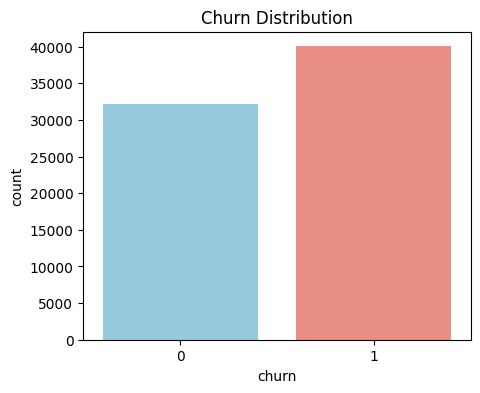

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x='churn', data=df, palette=['skyblue','salmon'])
plt.title("Churn Distribution")
plt.show()

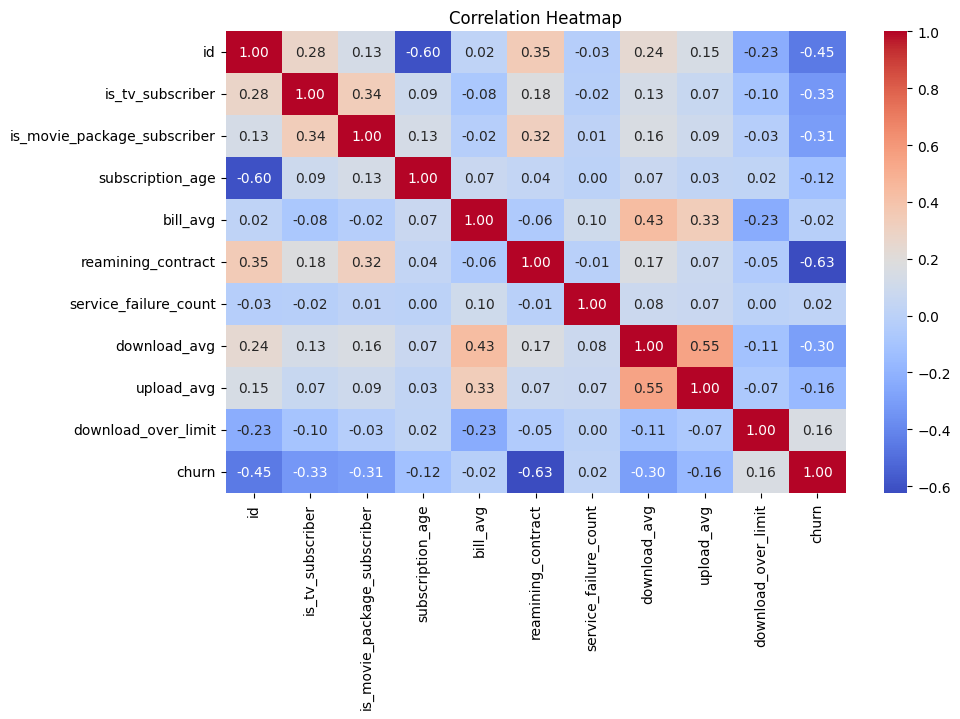

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

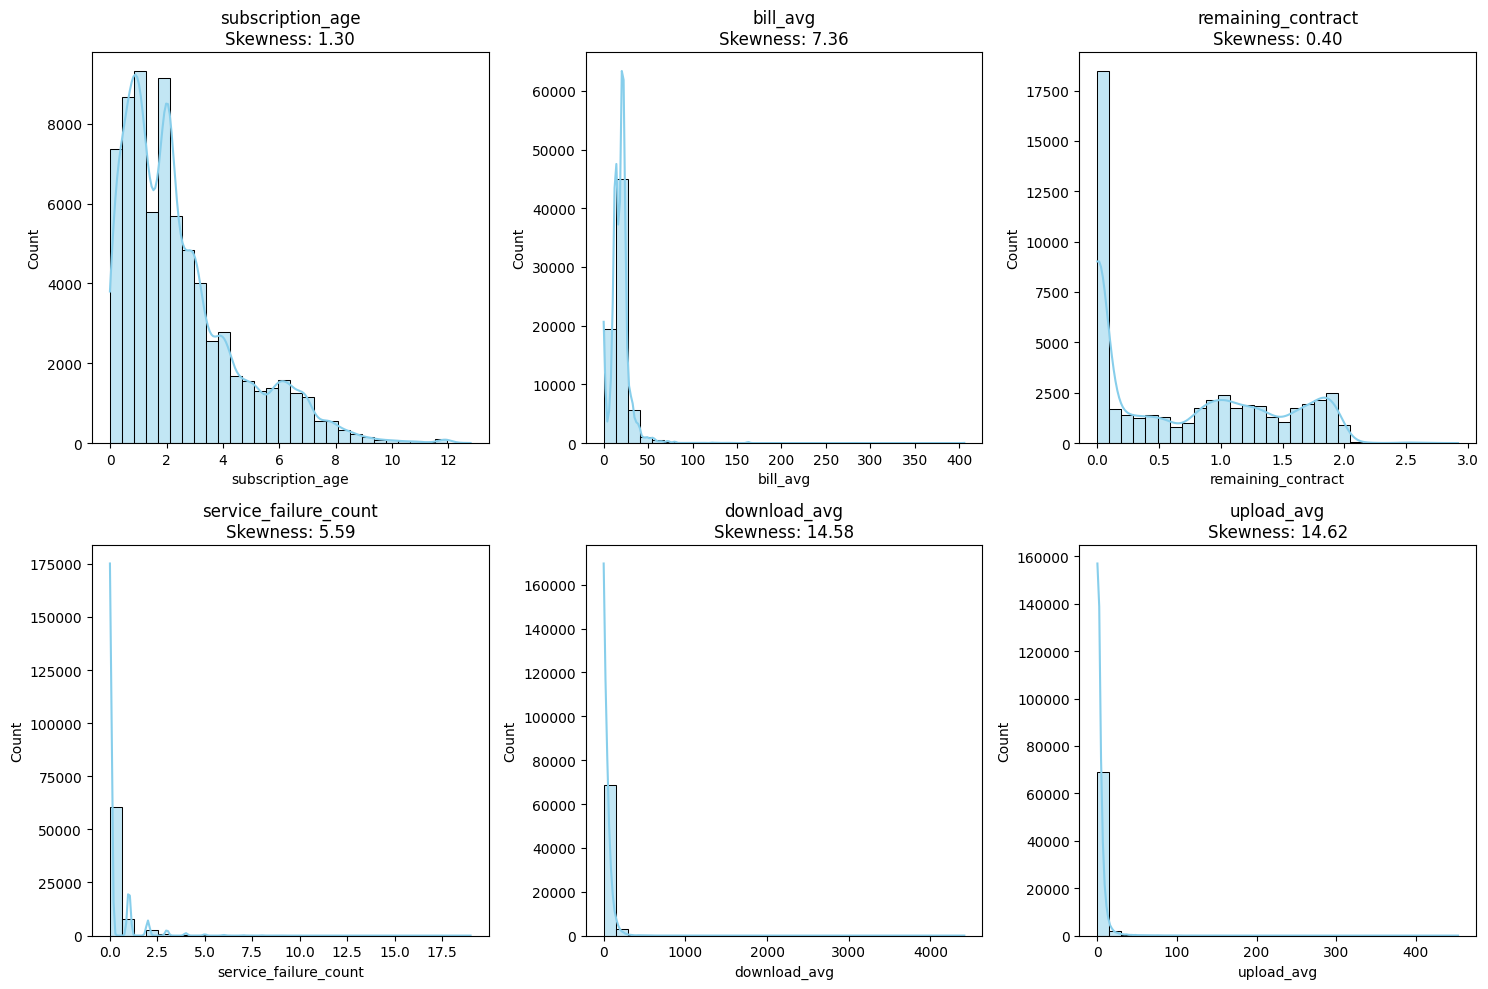

In [15]:
numeric_cols = [
    'subscription_age',
    'bill_avg',
    'remaining_contract',
    'service_failure_count',
    'download_avg',
    'upload_avg'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='skyblue',edgecolor='black')
    skewness = skew(df[col].dropna())
    plt.title(f"{col}\nSkewness: {skewness:.2f}")

plt.tight_layout()
plt.show()

## 3. Data Cleaning

In [16]:
df1 = df.copy()

In [17]:

df1.rename(columns={
    'reamining_contract': 'remaining_contract',
    'is_tv_subscriber': 'tv_subscriber',
    'is_movie_package_subscriber': 'movie_package_subscriber',
}, inplace=True)

print(df1.columns)

Index(['id', 'tv_subscriber', 'movie_package_subscriber', 'subscription_age',
       'bill_avg', 'remaining_contract', 'service_failure_count',
       'download_avg', 'upload_avg', 'download_over_limit', 'churn'],
      dtype='object')


according to the domain knowledge ill fill nan with 0

In [18]:
df1['remaining_contract'] = df1['remaining_contract'].fillna(0)

to decide whether to impute missing values for download_avg & upload_avg based on subscription_age or avg_bill 
ill check which variable has a stronger relationship with usage, here ill see how strongly download_avg / upload_avg correlate with subscription_age vs bill_avg.

In [19]:
print("Correlation with download_avg:")
print(df1[['subscription_age', 'bill_avg', 'download_avg']].corr()['download_avg'])

print("\nCorrelation with upload_avg:")
print(df1[['subscription_age', 'bill_avg', 'upload_avg']].corr()['upload_avg'])

Correlation with download_avg:
subscription_age    0.069331
bill_avg            0.431674
download_avg        1.000000
Name: download_avg, dtype: float64

Correlation with upload_avg:
subscription_age    0.030277
bill_avg            0.334236
upload_avg          1.000000
Name: upload_avg, dtype: float64


this shows which grouping produces a more gradual, logical progression of values

In [15]:
age_group_medians = df1.groupby(pd.qcut(df1['subscription_age'], q=5))[['download_avg','upload_avg']].median()

bill_group_medians = df1.groupby(pd.qcut(df1['bill_avg'], q=5))[['download_avg','upload_avg']].median()

print("\nMedian values by subscription_age groups:\n", age_group_medians)
print("\nMedian values by avg_bill groups:\n", bill_group_medians)


Median values by subscription_age groups:
                   download_avg  upload_avg
subscription_age                          
(-0.021, 0.76]            25.4         1.8
(0.76, 1.52]              29.4         2.2
(1.52, 2.32]              20.2         1.6
(2.32, 3.9]               27.0         2.1
(3.9, 12.8]               36.8         2.8

Median values by avg_bill groups:
                 download_avg  upload_avg
bill_avg                                
(-0.001, 12.0]          12.2         0.9
(12.0, 16.0]            32.8         2.5
(16.0, 21.0]            26.7         2.0
(21.0, 24.0]            24.7         1.9
(24.0, 406.0]           50.7         4.0


/tmp/ipykernel_13/2601865872.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_medians = df1.groupby(pd.qcut(df1['subscription_age'], q=5))[['download_avg','upload_avg']].median()
/tmp/ipykernel_13/2601865872.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bill_group_medians = df1.groupby(pd.qcut(df1['bill_avg'], q=5))[['download_avg','upload_avg']].median()


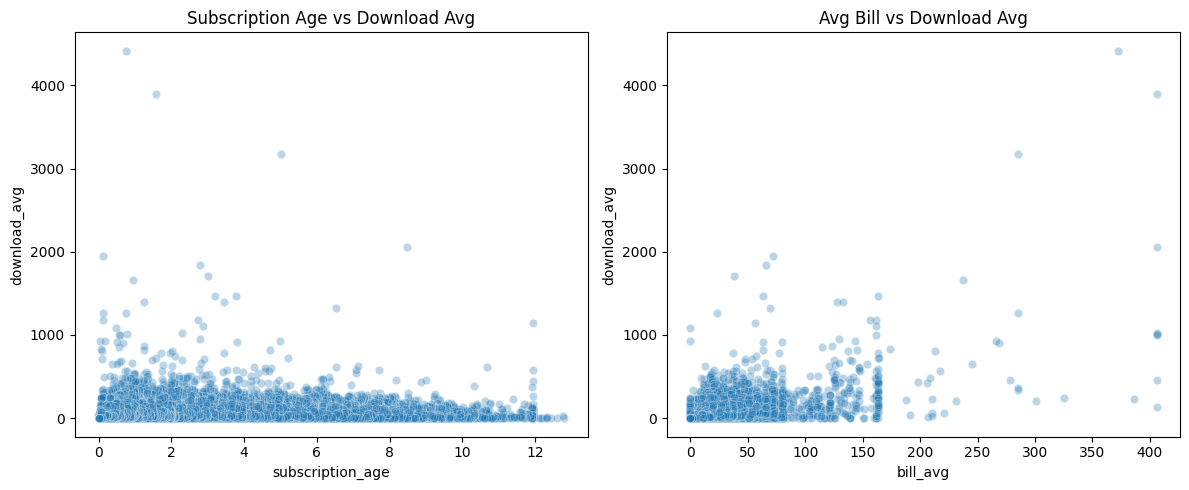

In [16]:

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x='subscription_age', y='download_avg', data=df1, alpha=0.3)
plt.title("Subscription Age vs Download Avg")

plt.subplot(1,2,2)
sns.scatterplot(x='bill_avg', y='download_avg', data=df1, alpha=0.3)
plt.title("Avg Bill vs Download Avg")

plt.tight_layout()
plt.show()

check if someone has download_avg as 0 yet payed a bill

In [17]:
zero_download_paid = df1[(df1['download_avg'] == 0) & (df1['bill_avg'] > 0)]

print("Number of customers with 0 downloads but paid a bill:", len(zero_download_paid))
display(zero_download_paid.head(10))

Number of customers with 0 downloads but paid a bill: 7769


,id,tv_subscriber,movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
3,27,0,0,6.87,21,0.00,1,0.0,0.0,0,1
7,84,0,0,5.48,14,0.00,1,0.0,0.0,0,1
12,213,0,0,6.64,10,0.00,0,0.0,0.0,0,1
13,222,0,0,5.53,14,0.00,0,0.0,0.0,0,1
14,270,0,0,6.97,23,0.28,0,0.0,0.0,0,1
17,417,0,0,6.45,40,0.00,0,0.0,0.0,0,1
18,475,0,0,6.81,14,0.00,0,0.0,0.0,0,1
24,608,0,0,8.57,20,0.00,0,0.0,0.0,0,1
26,642,0,0,5.21,14,0.00,0,0.0,0.0,0,1
28,680,0,0,7.02,13,0.00,0,0.0,0.0,0,1


In [18]:
zero_download_paid.groupby(['tv_subscriber', 'movie_package_subscriber']).size()

tv_subscriber  movie_package_subscriber
0              0                           3763
1              0                           2740
               1                           1266
dtype: int64

In [19]:
print("Median bill (0 downloads, bill>0):", zero_download_paid['bill_avg'].median())
print("Median bill (download>0):", df[df['download_avg'] > 0]['bill_avg'].median())

Median bill (0 downloads, bill>0): 20.0
Median bill (download>0): 20.0


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


In [20]:
zero_download_paid['upload_avg'].value_counts().head()

upload_avg
0.0    7764
0.1       4
0.4       1
Name: count, dtype: int64

how i will fill nan for download_avg/upload_avg:

1. if customer is a tv_subscriber/movie_package_subscriber -> i will fill it with 0 bcoz the bill is most likely concerning these sevices

2. if customer is an internet user (meaning they arent subscribed to a service yet payed a bill) -> ill use the bill_avg column median as the imputation driver

In [20]:
mask_non_internet = (
    (df1['download_avg'].isna() | df1['upload_avg'].isna()) &
    ((df1['tv_subscriber'] == 1) | (df1['movie_package_subscriber'] == 1))
)
df1.loc[mask_non_internet, ['download_avg', 'upload_avg']] = 0

In [21]:
mask_internet = (
    (df1['download_avg'].isna() | df1['upload_avg'].isna()) &
    ((df1['tv_subscriber'] == 0) & (df1['movie_package_subscriber'] == 0))
)


df1['bill_bin'] = pd.qcut(df1['bill_avg'], q=10, duplicates='drop') 


df1['download_avg'] = df1.groupby('bill_bin')['download_avg'].transform(
    lambda x: x.fillna(x.median())
)
df1['upload_avg'] = df1.groupby('bill_bin')['upload_avg'].transform(
    lambda x: x.fillna(x.median())
)


df1 = df1.drop(columns=['bill_bin'])

C:\Users\user\AppData\Local\Temp\ipykernel_26804\3556447712.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1['download_avg'] = df1.groupby('bill_bin')['download_avg'].transform(
C:\Users\user\AppData\Local\Temp\ipykernel_26804\3556447712.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1['upload_avg'] = df1.groupby('bill_bin')['upload_avg'].transform(


In [22]:
df1.isna().sum()

id                          0
tv_subscriber               0
movie_package_subscriber    0
subscription_age            0
bill_avg                    0
remaining_contract          0
service_failure_count       0
download_avg                0
upload_avg                  0
download_over_limit         0
churn                       0
dtype: int64

In [23]:
df1 = df1.drop(columns=['id'])

## 4. EDA

I used log1p to reduce skewness, handle outliers, and make the numeric features more suitable for machine learning models


In [24]:
cols = ['bill_avg',
       'download_avg', 'upload_avg']
print("Original Skewness:")
for col in cols:
    print(f"{col}: {skew(df1[col].dropna()):.2f}")

for col in cols:
    df1[col + '_1'] = np.log1p(df1[col])

print("\nSkewness after log1p:")
for col in cols:
    print(f"{col}_1: {skew(df1[col + '_1'].dropna()):.2f}")

Original Skewness:
bill_avg: 7.36
download_avg: 14.58
upload_avg: 14.64

Skewness after log1p:
bill_avg_1: -2.12
download_avg_1: -0.65
upload_avg_1: 0.59


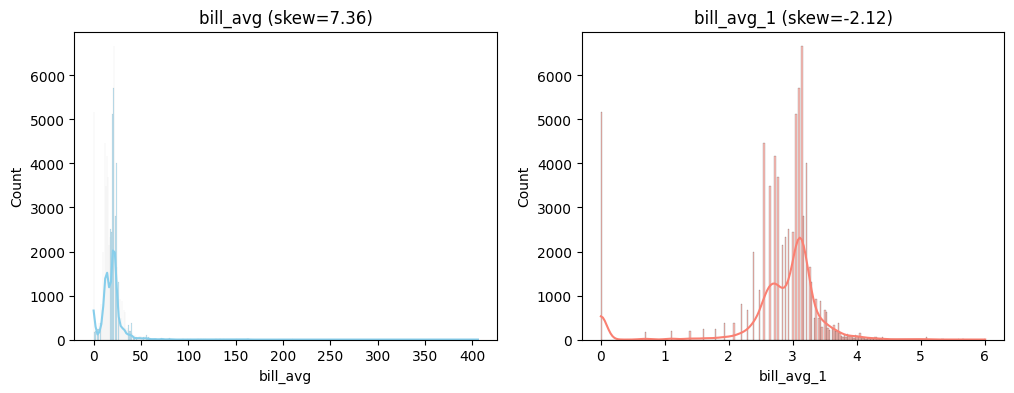

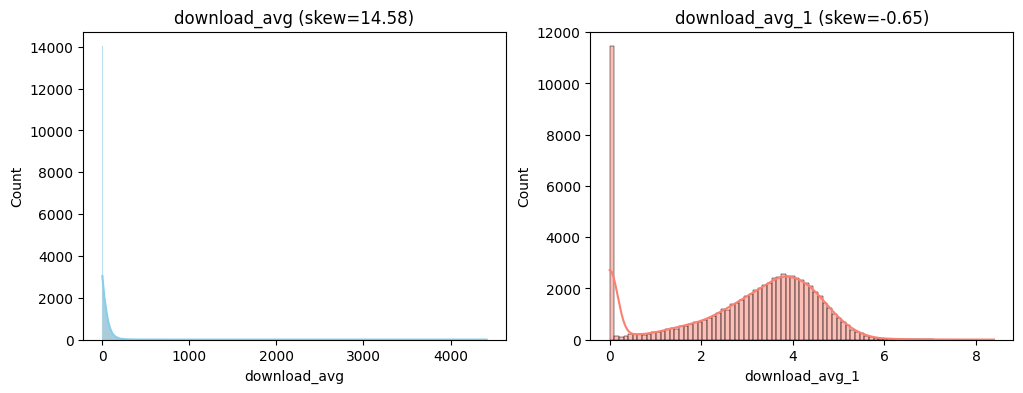

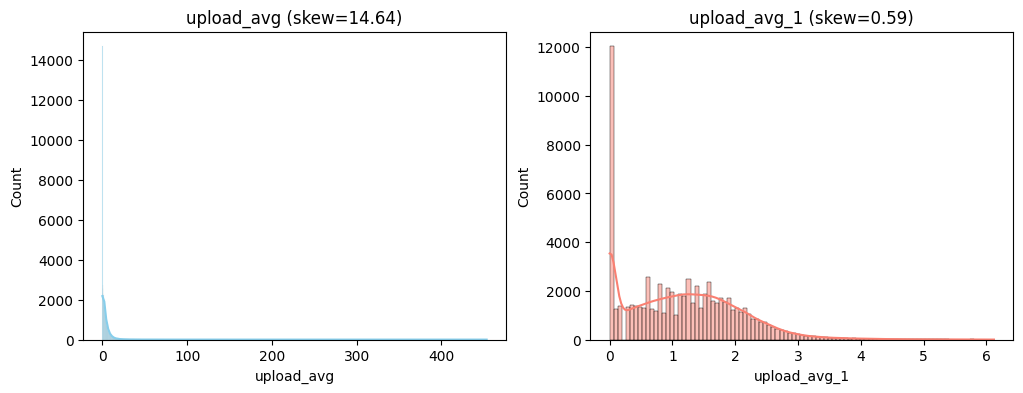

In [25]:
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))


    sns.histplot(df1[col].dropna(), kde=True, ax=axes[0], color="skyblue", edgecolor="black")
    axes[0].set_title(f"{col} (skew={skew(df1[col].dropna()):.2f})")

    sns.histplot(df1[col + '_1'].dropna(), kde=True, ax=axes[1], color="salmon", edgecolor="black")
    axes[1].set_title(f"{col}_1 (skew={skew(df1[col + '_1'].dropna()):.2f})")

    plt.show()

In [26]:
df1['service_failure_count_1'] = np.sqrt(df1['service_failure_count'])

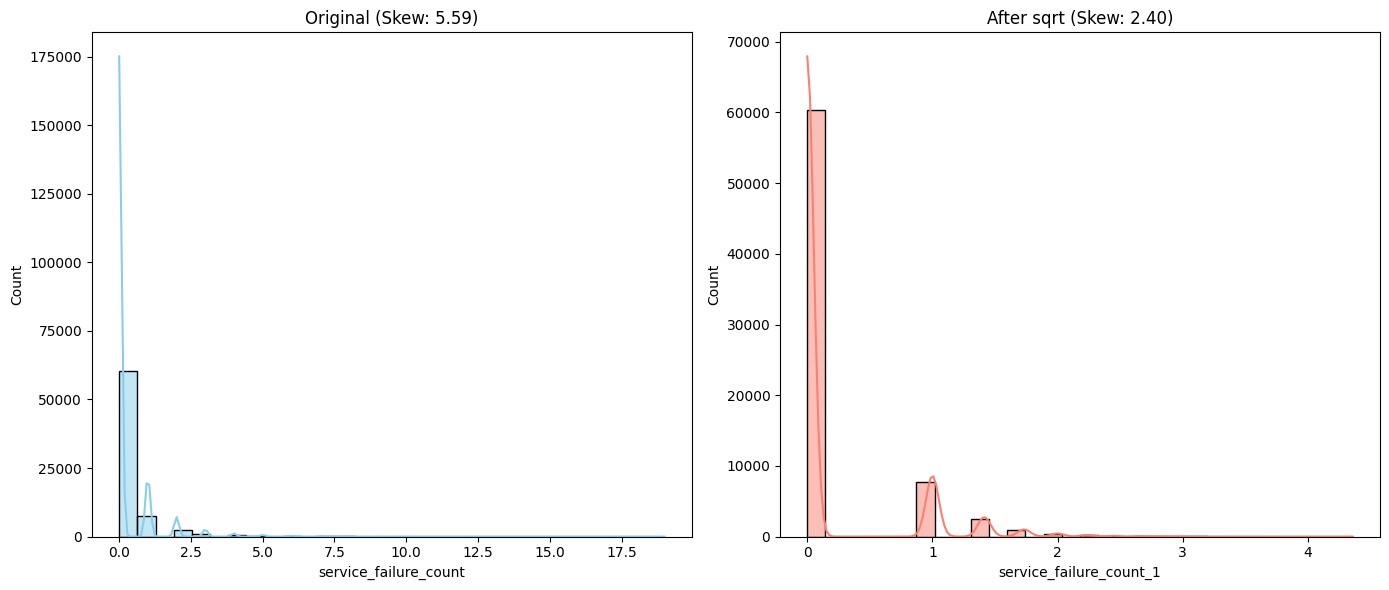

In [27]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.histplot(df1['service_failure_count'].dropna(), bins=30, kde=True, color="skyblue")
plt.title(f"Original (Skew: {skew(df1['service_failure_count'].dropna()):.2f})")

plt.subplot(1,2,2)
sns.histplot(df1['service_failure_count_1'].dropna(), bins=30, kde=True, color="salmon")
plt.title(f"After sqrt (Skew: {skew(df1['service_failure_count_1'].dropna()):.2f})")

plt.tight_layout()
plt.show()


ill use power transformer method "yeo-jhonson" on bill avg column and seevice failure count for further improvement

In [29]:

pt = PowerTransformer(method='yeo-johnson')

cols1 = ['bill_avg_1', 'service_failure_count_1']

df1[[col for col in cols1]] = pt.fit_transform(df1[cols1])

In [30]:
for col in cols1:
    print(f"{col}: {skew(df1[col].dropna()):.2f}")

bill_avg_1: 0.10
service_failure_count_1: 1.81


In [31]:
df1.head()

,tv_subscriber,movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,bill_avg_1,download_avg_1,upload_avg_1,service_failure_count_1
0,1,0,11.95,25,0.14,0,8.4,2.3,0,0,0.659809,2.240710,1.193922,-0.443226
1,0,0,8.22,0,0.00,0,0.0,0.0,0,1,-2.388366,0.000000,0.000000,-0.443226
2,1,0,8.91,16,0.00,0,13.7,0.9,0,1,-0.115703,2.687847,0.641854,-0.443226
3,0,0,6.87,21,0.00,1,0.0,0.0,0,1,0.338042,0.000000,0.000000,2.251898
4,0,0,6.39,0,0.00,0,0.0,0.0,0,1,-2.388366,0.000000,0.000000,-0.443226


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


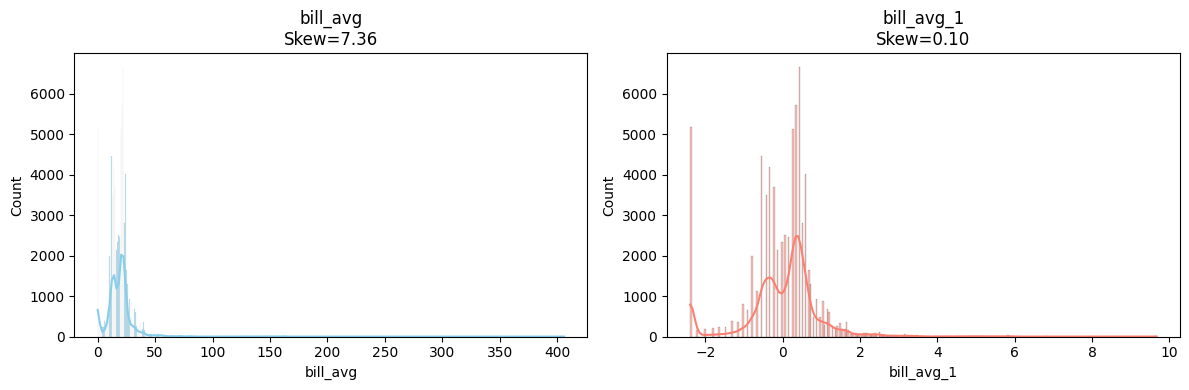

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


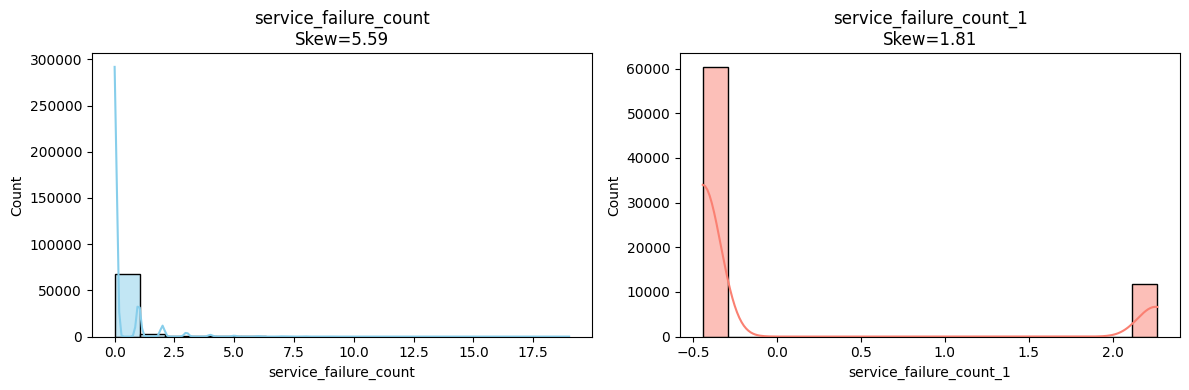

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


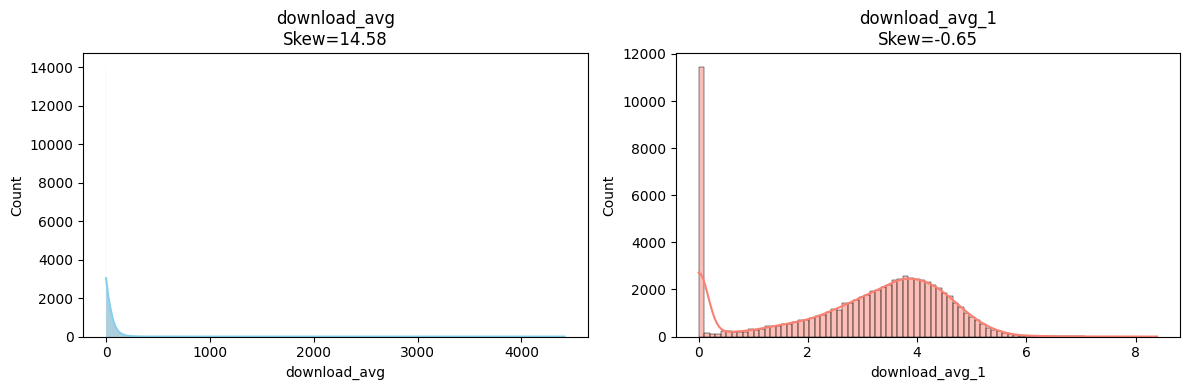

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


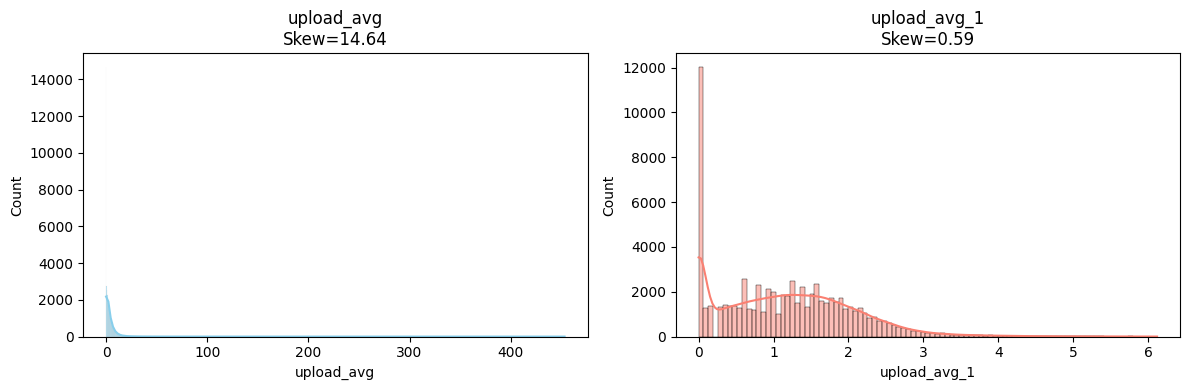

In [32]:
pairs = [
    ("bill_avg", "bill_avg_1"),
    ("service_failure_count", "service_failure_count_1"),
    ("download_avg", "download_avg_1"),
    ("upload_avg", "upload_avg_1")
]

for original, transformed in pairs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df1[original].dropna(), kde=True, color="skyblue", edgecolor="black", ax=axes[0])
    axes[0].set_title(f"{original}\nSkew={skew(df1[original].dropna()):.2f}")

    sns.histplot(df1[transformed].dropna(), kde=True, color="salmon", edgecolor="black", ax=axes[1])
    axes[1].set_title(f"{transformed}\nSkew={skew(df1[transformed].dropna()):.2f}")

    plt.tight_layout()
    plt.show()

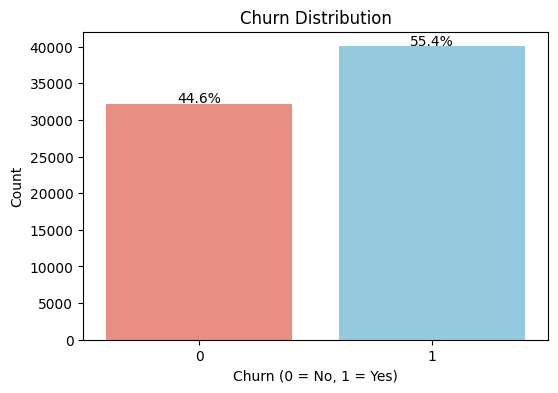

In [33]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='churn', data=df1, palette={'skyblue', 'salmon'})
total = len(df1)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 200,   # adjust +200 if labels overlap
            f'{100*height/total:.1f}%', ha='center')

plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_13/4004212236.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='churn', y=col, data=df1,palette={'skyblue', 'salmon'}, estimator='mean', ci=None)


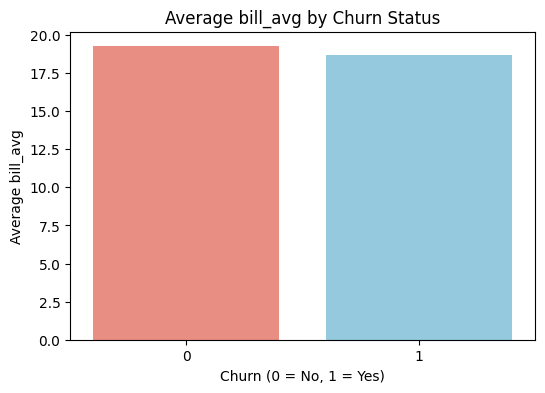

/tmp/ipykernel_13/4004212236.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='churn', y=col, data=df1,palette={'skyblue', 'salmon'}, estimator='mean', ci=None)


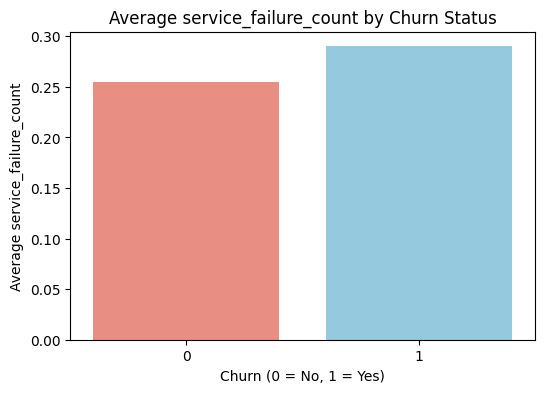

/tmp/ipykernel_13/4004212236.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='churn', y=col, data=df1,palette={'skyblue', 'salmon'}, estimator='mean', ci=None)


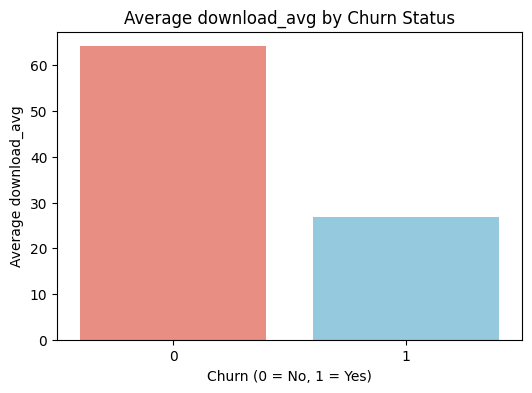

/tmp/ipykernel_13/4004212236.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='churn', y=col, data=df1,palette={'skyblue', 'salmon'}, estimator='mean', ci=None)


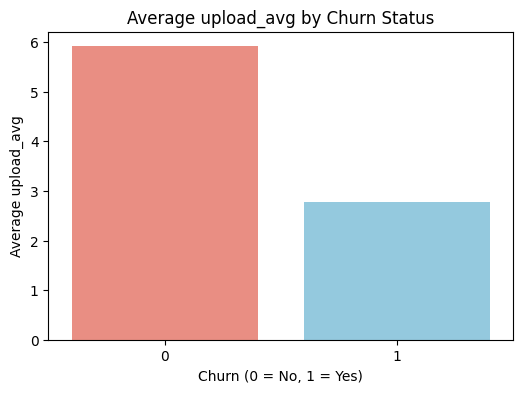

/tmp/ipykernel_13/4004212236.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='churn', y=col, data=df1,palette={'skyblue', 'salmon'}, estimator='mean', ci=None)


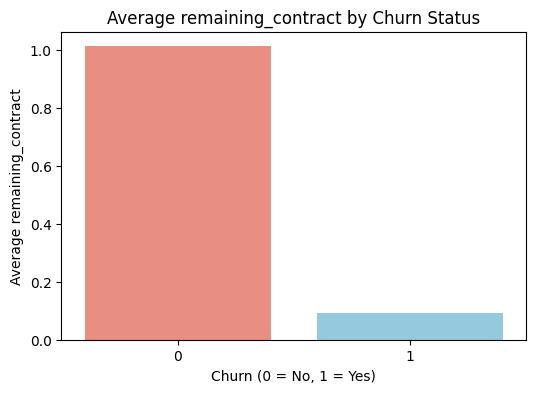

/tmp/ipykernel_13/4004212236.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='churn', y=col, data=df1,palette={'skyblue', 'salmon'}, estimator='mean', ci=None)


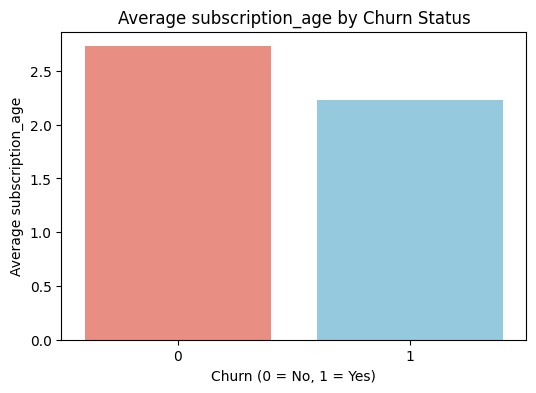

In [34]:

numeric_cols_1 = ['bill_avg', 'service_failure_count', 'download_avg', 'upload_avg','remaining_contract','subscription_age']
'''for col in numeric_cols_1:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='churn', y=col, data=df1,palette={'skyblue', 'salmon'})
    plt.title(f"{col} vs Churn")
    plt.xlabel("Churn (0 = No, 1 = Yes)")
    plt.ylabel(col)
    plt.show()
'''
for col in numeric_cols_1:
    plt.figure(figsize=(6,4))
    sns.barplot(x='churn', y=col, data=df1,palette={'skyblue', 'salmon'}, estimator='mean', ci=None)
    plt.title(f"Average {col} by Churn Status")
    plt.xlabel("Churn (0 = No, 1 = Yes)")
    plt.ylabel(f"Average {col}")
    plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


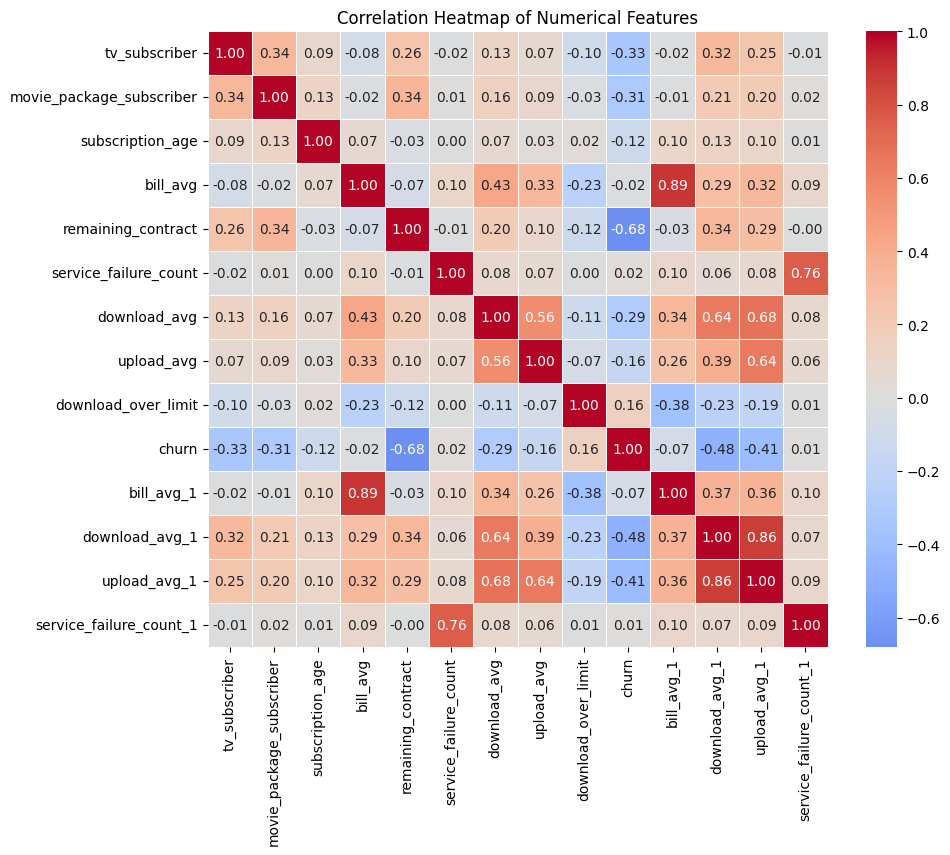

In [35]:
numeric_cols_1 = df1.select_dtypes(include=['int64', 'float64']).columns

corr = df1[numeric_cols_1].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

##  5. Feature Engineering

In [28]:
df2 = df1.copy()

In [30]:
df2['bill_avg_per_gb'] = df2['bill_avg'] / (df2['download_avg'] + df2['upload_avg'] + 1)
df2['avg_usage'] = df2['download_avg'] + df2['upload_avg']

In [31]:
df2['near_contract_end'] = (df2['remaining_contract'] <= 1).astype(int)

Churn % by near_contract_end:
churn                      0          1
near_contract_end                      
0                  89.683843  10.316157
1                  28.635912  71.364088


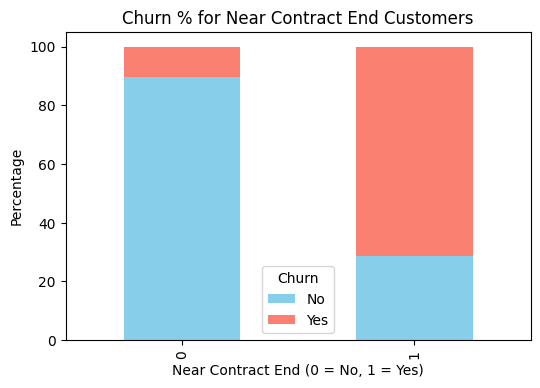

In [32]:

churn_contract = pd.crosstab(df2['near_contract_end'], df2['churn'], normalize='index') * 100

print("Churn % by near_contract_end:")
print(churn_contract)
colors = ["skyblue", "salmon"]
churn_contract.plot(kind='bar', stacked=True, figsize=(6,4), color = colors)
plt.title("Churn % for Near Contract End Customers")
plt.xlabel("Near Contract End (0 = No, 1 = Yes)")
plt.ylabel("Percentage")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.show()


In [33]:
df2['new_customer'] = (df2['subscription_age'] < 1).astype(int)

C:\Users\user\AppData\Local\Temp\ipykernel_26804\4087413886.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


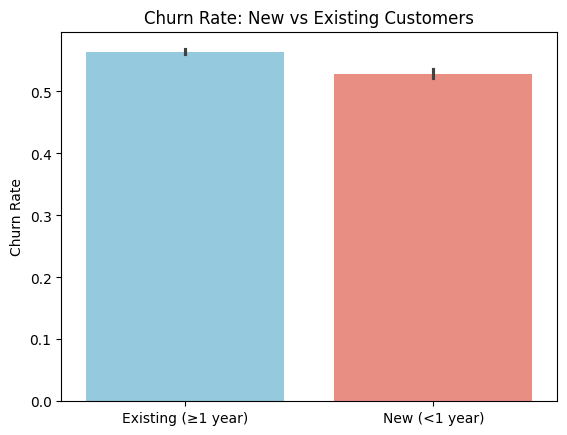

In [34]:
sns.barplot(
    data=df2,
    x='new_customer',
    y='churn',
    palette=['skyblue', 'salmon']
)
plt.title("Churn Rate: New vs Existing Customers")
plt.xticks([0,1], ['Existing (≥1 year)', 'New (<1 year)'])
plt.ylabel("Churn Rate")
plt.xlabel("")
plt.show()

In [35]:

df2['has_extra_services'] = ((df2['tv_subscriber'] + df2['movie_package_subscriber']) > 0).astype(int)
df2['bundle_size'] = df2['tv_subscriber'] + df2['movie_package_subscriber']


## 6. Unsupervised Learning

In [36]:
numeric_cols_2 = [
    'subscription_age',
    'bill_avg',
    'remaining_contract',
    'service_failure_count',
    'download_avg',
    'upload_avg',
    'bill_avg_per_gb', 
    'avg_usage',
]


scaler = MinMaxScaler()
df2[numeric_cols_2] = scaler.fit_transform(df2[numeric_cols_2])

df2[numeric_cols_2].head()

,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,bill_avg_per_gb,avg_usage
0,0.933697,0.061576,0.047945,0.000000,0.001903,0.005074,0.013109,0.002317
1,0.642746,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.696568,0.039409,0.000000,0.000000,0.003103,0.001985,0.006292,0.003162
3,0.537441,0.051724,0.000000,0.052632,0.000000,0.000000,0.128834,0.000000
4,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [37]:
X = df2[numeric_cols_2]

In [38]:
inertia = []
K_range = range(1, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

ill look for elbow point where line is least slope (interia stops decreasing sharply)

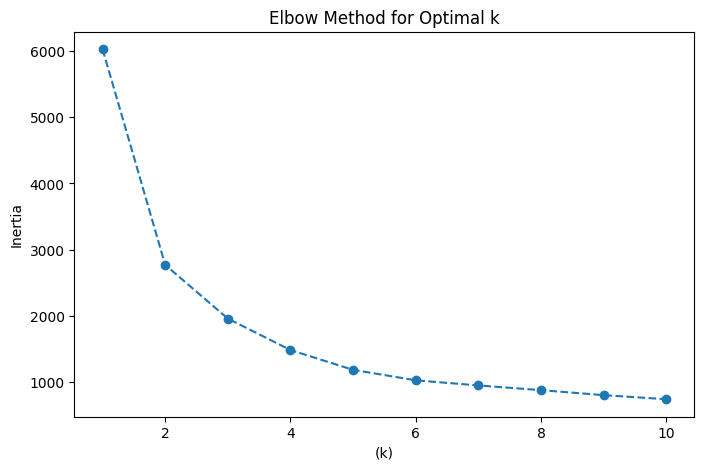

In [46]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel("(k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [47]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df2['cluster'] = kmeans.fit_predict(X)

print(df2['cluster'].value_counts())

cluster
0    37393
1    22596
2    12285
Name: count, dtype: int64


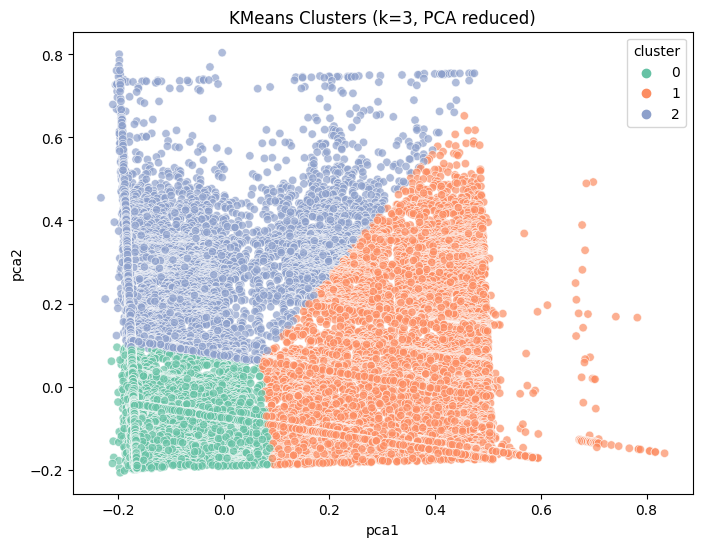

In [48]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df2['pca1'] = X_pca[:,0]
df2['pca2'] = X_pca[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df2, x='pca1', y='pca2', hue='cluster', palette='Set2', alpha=0.7)
plt.title("KMeans Clusters (k=3, PCA reduced)")
plt.show()

cluster
0    0.840237
1    0.102496
2    0.514042
Name: churn, dtype: float64


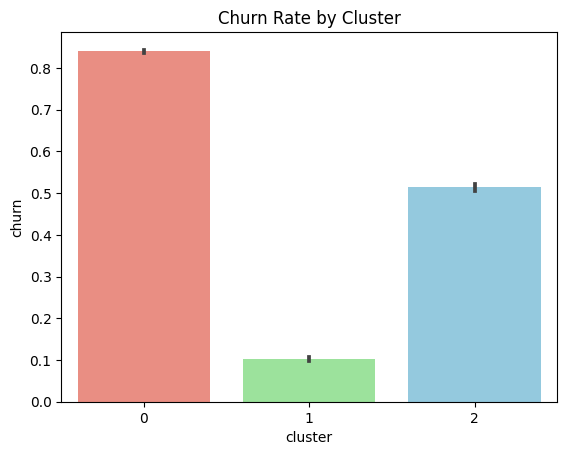

In [49]:
cluster_churn = df2.groupby('cluster')['churn'].mean()
print(cluster_churn)

sns.barplot(data=df2, x='cluster', y='churn', palette={'salmon', 'skyblue', 'lightgreen'})
plt.title("Churn Rate by Cluster")
plt.show()

In [39]:
cluster_profile = df2.groupby('cluster')[numeric_cols_2].mean().round(2)

cluster_profile['churn_rate'] = df2.groupby('cluster')['churn'].mean().round(2)

cluster_profile['count'] = df2['cluster'].value_counts()

print(cluster_profile)

KeyError: 'cluster'

**Cluster 0**

1. Very low subscription age (0.13, scaled) → mostly new customers

2. Very low contract (0.02) → no/short contract commitment.

3. Very high churn rate (84%)

Group size: 37k customers (largest group)

*At risk new customers. They join, don’t have contracts, and leave quickly.*

**Cluster 1**

1. Low bill (0.04) + low usage

2. Long remaining contracts (0.48) → many are locked into contracts

3. Very low churn rate (10%)

Group size: ~22k

 *Interpretation: Stable contract customers. Low usage, low bills, but committed*

**Cluster 2**

1. Higher subscription age (0.44) → more experienced customers

2. Slightly higher service failures (0.02)

3. Medium churn rate (51%)

Group size: ~12k customers (smallest group)


 *Interpretation: Older customers who churn moderately, maybe frustrated with service failures or seeking alternatives.*

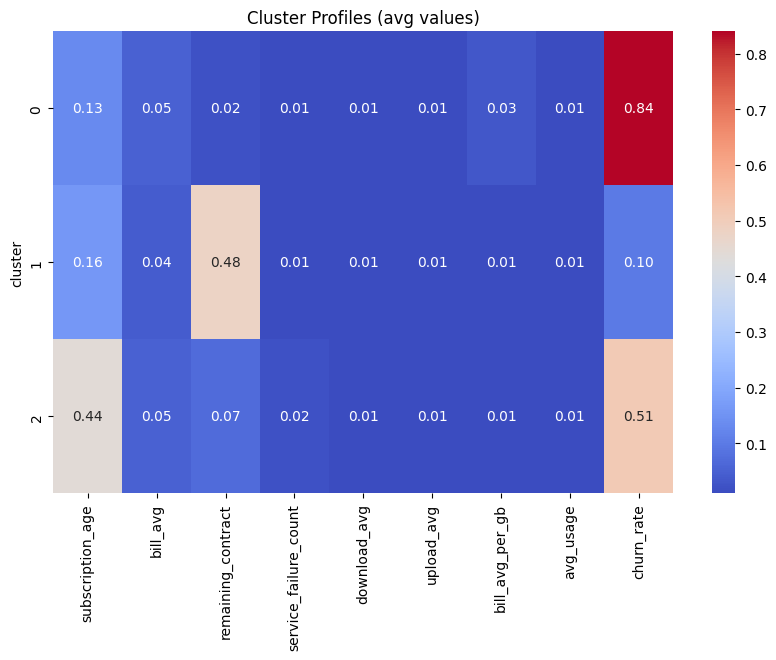

In [51]:
plt.figure(figsize=(10,6))
sns.heatmap(cluster_profile.drop(columns='count'), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cluster Profiles (avg values)")
plt.show()


* Biggest churn risk = **Cluster 0** (new customers with no contracts)

* Most valuable stable customers = **Cluster 1** (contract-locked)

* Somewhere in between, loyal but at risk due to issues = **Cluster 2** (most subcription age)

## 7. Supervised learning 

In [40]:

X = df2[numeric_cols_2 + ['near_contract_end', 'new_customer']]  
y = df2['churn']


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [42]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [43]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:199: UserWarning: [14:01:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))
    print()


--- Logistic Regression ---
Accuracy: 0.8840539605672778
Precision: 0.8742614039234223
Recall: 0.9235955056179775
F1 Score: 0.898251578436134
ROC AUC: 0.9402618429833152

--- Random Forest ---
Accuracy: 0.9364233829124871
Precision: 0.9520591610353181
Recall: 0.9322097378277153
F1 Score: 0.9420298997035261
ROC AUC: 0.9746621997909907

--- XGBoost ---
Accuracy: 0.9367001037703216
Precision: 0.9505906261907786
Recall: 0.9343320848938826
F1 Score: 0.942391235912611
ROC AUC: 0.9769408293938241



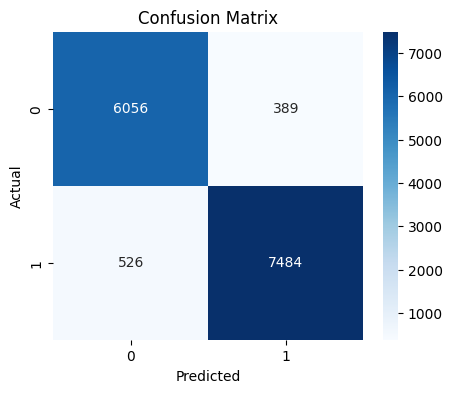

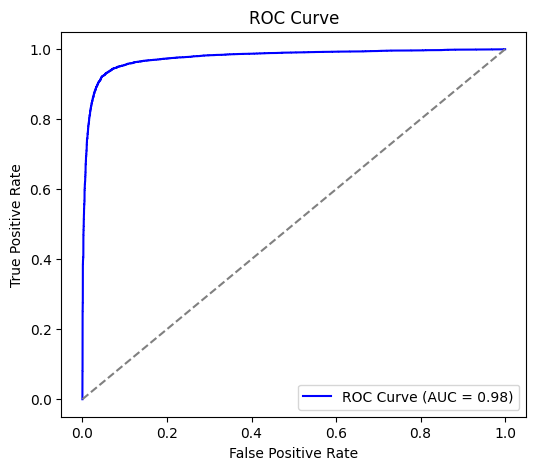

In [48]:
## Confusion matrix and ROC AUC curve
# --- Step 4: Predict ---

from sklearn.metrics import confusion_matrix, roc_curve, auc, RocCurveDisplay

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # for ROC-AUC

# --- Step 5: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Step 6: ROC Curve and AUC ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [52]:
log_reg.coef_
coefficients = log_reg.coef_[0]

# Create DataFrame with feature names and coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Importance': abs(coefficients)  # magnitude of impact
}).sort_values(by='Importance', ascending=False)

# Display top features
print(feature_importance)

                 Feature  Coefficient  Importance
6        bill_avg_per_gb    21.477237   21.477237
2     remaining_contract   -15.010082   15.010082
4           download_avg    -8.365346    8.365346
7              avg_usage    -8.290514    8.290514
1               bill_avg    -3.391881    3.391881
0       subscription_age    -3.220062    3.220062
5             upload_avg    -2.971045    2.971045
8      near_contract_end    -2.897939    2.897939
3  service_failure_count     2.187156    2.187156
9           new_customer     0.090592    0.090592


In [53]:
feature_importance

,Feature,Coefficient,Importance
6,bill_avg_per_gb,21.477237,21.477237
2,remaining_contract,-15.010082,15.010082
4,download_avg,-8.365346,8.365346
7,avg_usage,-8.290514,8.290514
1,bill_avg,-3.391881,3.391881
0,subscription_age,-3.220062,3.220062
5,upload_avg,-2.971045,2.971045
8,near_contract_end,-2.897939,2.897939
3,service_failure_count,2.187156,2.187156
9,new_customer,0.090592,0.090592


## 8. Predicting bill avg

In [58]:
y_reg = df2['bill_avg']
X_reg = df2.drop(columns=['bill_avg', 'churn'])

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)

y_pred = rf_reg.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 5.428615739565868e-07
R²: 0.9995290421852921
